<a href="https://colab.research.google.com/github/acchu1907/CustomerChurn/blob/main/CustomerChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap xgboost imbalanced-learn


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap

df = pd.read_csv('Customer_Data.csv')

df['minimum_payments'] = df['minimum_payments'].fillna(df['minimum_payments'].median())
df['credit_limit'] = df['credit_limit'].fillna(df['credit_limit'].median())

df['churn'] = np.where((df['purchases_frequency'] < 0.1) & (df['purchases'] < 100), 1, 0)

X = df.drop(['cust_id', 'churn'], axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

def get_risk_level(p):
    if p > 0.8: return "High Risk"
    elif p > 0.4: return "Medium Risk"
    else: return "Low Risk"

results = pd.DataFrame({
    'Actual_Churn': y_test,
    'Churn_Probability': probs
})
results['Risk_Level'] = results['Churn_Probability'].apply(get_risk_level)

Step 1: Data Loaded Successfully.
Step 2: Churn labels created. Total churners identified: 2393
Step 3: Model training complete.

--- SAMPLE PREDICTIONS ---
   Probability Risk_Level
0     0.996914  High Risk
1     0.000130   Low Risk
2     0.000061   Low Risk
3     0.000043   Low Risk
4     0.000035   Low Risk
5     0.000067   Low Risk
6     0.000149   Low Risk
7     0.000088   Low Risk
8     0.000041   Low Risk
9     0.999906  High Risk

Step 4: Generating SHAP Plots (This may take a minute)...


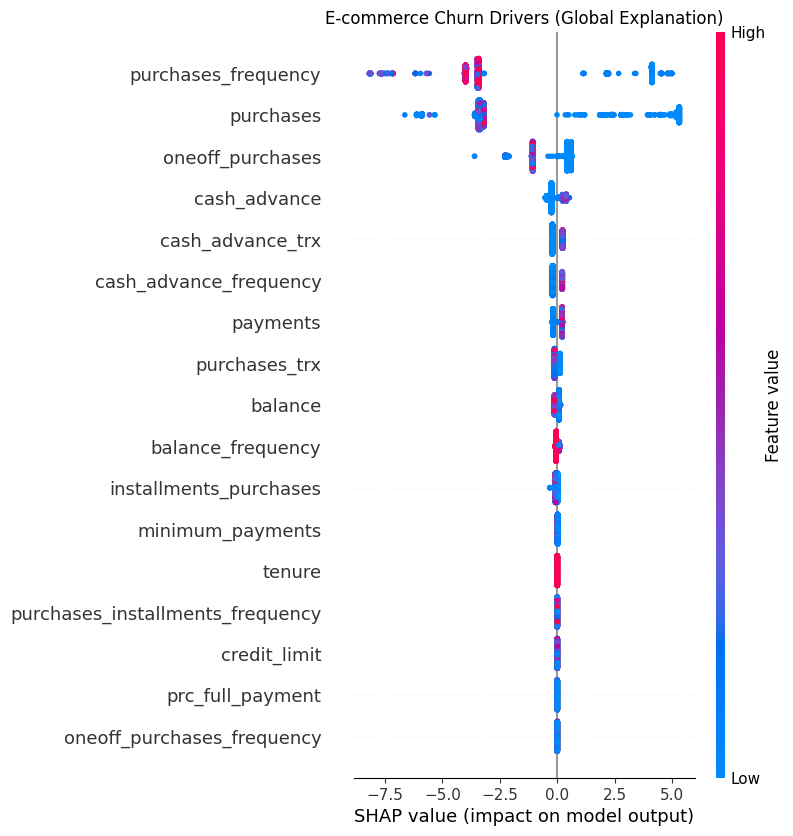


Step 5: Visualizing individual customer risk...


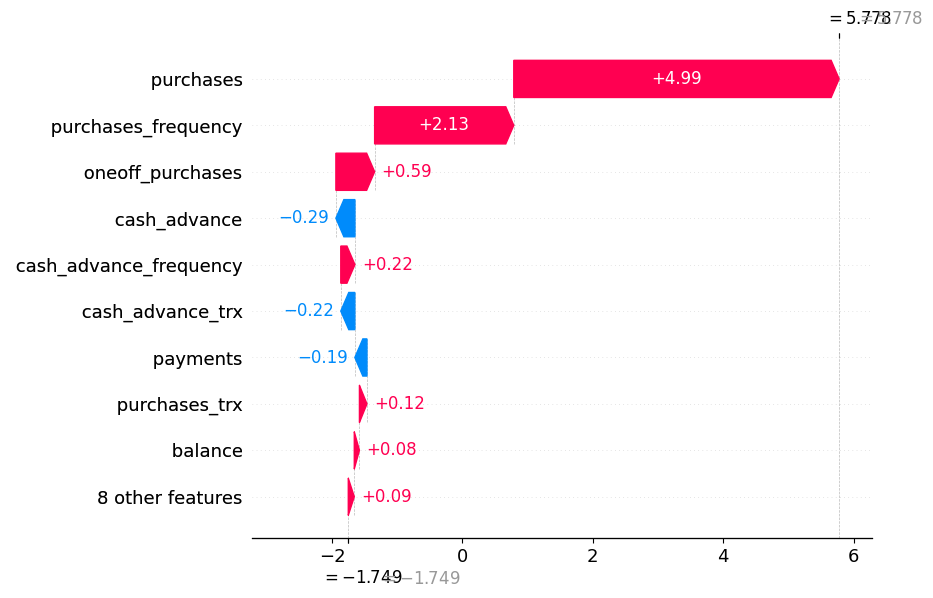

In [ ]:
!pip install shap xgboost imbalanced-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

try:
    df = pd.read_csv('Customer_Data.csv')
    print("Step 1: Data Loaded Successfully.")
except:
    print("Error: Ensure Customer_Data.csv is uploaded in the left sidebar!")

df['minimum_payments'] = df['minimum_payments'].fillna(df['minimum_payments'].median())
df['credit_limit'] = df['credit_limit'].fillna(df['credit_limit'].median())

df['churn'] = np.where((df['purchases_frequency'] < 0.1) & (df['purchases'] < 100), 1, 0)
print(f"Step 2: Churn labels created. Total churners identified: {df['churn'].sum()}")

X = df.drop(['cust_id', 'churn'], axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#XGBoost Model
model = xgb.XGBClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)
print("Step 3: Model training complete.")

probs = model.predict_proba(X_test)[:, 1]
def get_risk(p):
    if p > 0.8: return "High Risk"
    elif p > 0.4: return "Medium Risk"
    else: return "Low Risk"

results = pd.DataFrame({'Probability': probs})
results['Risk_Level'] = results['Probability'].apply(get_risk)

print("\n--- SAMPLE PREDICTIONS ---")
print(results.head(10))

print("\nStep 4: Generating SHAP Plots (This may take a minute)...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("E-commerce Churn Drivers (Global Explanation)")
plt.show()

print("\nStep 5: Visualizing individual customer risk...")
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[0], X_test.iloc[0], show=True)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1308
           1       1.00      1.00      1.00       482

    accuracy                           1.00      1790
   macro avg       1.00      1.00      1.00      1790
weighted avg       1.00      1.00      1.00      1790



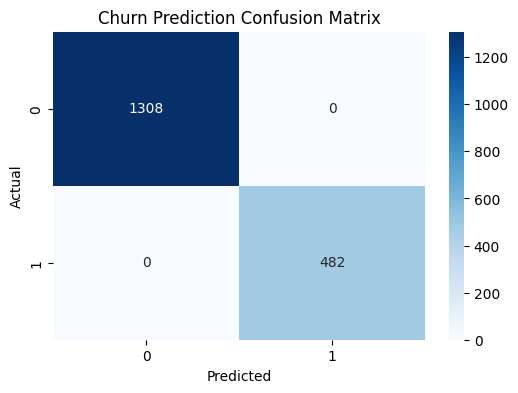

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Churn Prediction Confusion Matrix')
plt.show()

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model.fit(X_train_res, y_train_res)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
print("--- MODEL PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix: Hits vs. Misses")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
all_probs = model.predict_proba(X)[:, 1]

df_final = df.copy()
df_final['Churn_Probability'] = all_probs

def segment_risk(p):
    if p > 0.8: return "High Risk"
    elif p > 0.4: return "Medium Risk"
    else: return "Low Risk"

df_final['Risk_Level'] = df_final['Churn_Probability'].apply(segment_risk)

print("\n--- CUSTOMER RISK SEGMENTATION ---")
print(df_final['Risk_Level'].value_counts())

print("\nTop 5 High-Risk Customers:")
print(df_final[df_final['Risk_Level'] == 'High Risk'][['cust_id', 'Churn_Probability']].head())


--- CUSTOMER RISK SEGMENTATION ---
Risk_Level
Low Risk       6557
High Risk      2392
Medium Risk       1
Name: count, dtype: int64

Top 5 High-Risk Customers:
   cust_id  Churn_Probability
1   C10002           0.999753
4   C10005           0.999249
14  C10015           0.999462
16  C10017           0.999753
24  C10025           0.999753


In [ ]:
all_probs = model.predict_proba(X)[:, 1]

df_final = df.copy()
df_final['Churn_Probability'] = all_probs

def get_risk_tier(p):
    if p > 0.8: return "High Risk"
    elif p > 0.4: return "Medium Risk"
    else: return "Low Risk"

df_final['Risk_Level'] = df_final['Churn_Probability'].apply(get_risk_tier)

def get_action(row):
    if row['Risk_Level'] == 'High Risk':
        return "URGENT: 25% Discount + 48hr Expiry"
    elif row['Risk_Level'] == 'Medium Risk':
        return "NUDGE: Double Loyalty Points + Product Recommendations"
    else:
        return "UPSELL: Credit Limit Increase + Referral Bonus"

df_final['Recommended_Action'] = df_final.apply(get_action, axis=1)

df_final.to_csv('Customer_Action_Plan.csv', index=False)
print("Success! df_final created and suggestions saved.")
print(df_final[['cust_id', 'Risk_Level', 'Recommended_Action']].head())

Success! df_final created and suggestions saved.
  cust_id Risk_Level                              Recommended_Action
0  C10001   Low Risk  UPSELL: Credit Limit Increase + Referral Bonus
1  C10002  High Risk              URGENT: 25% Discount + 48hr Expiry
2  C10003   Low Risk  UPSELL: Credit Limit Increase + Referral Bonus
3  C10004   Low Risk  UPSELL: Credit Limit Increase + Referral Bonus
4  C10005  High Risk              URGENT: 25% Discount + 48hr Expiry


Total Revenue at Risk (High Risk Group): $17,013.87
Potential Revenue Saved (10% Conversion): $1,701.39


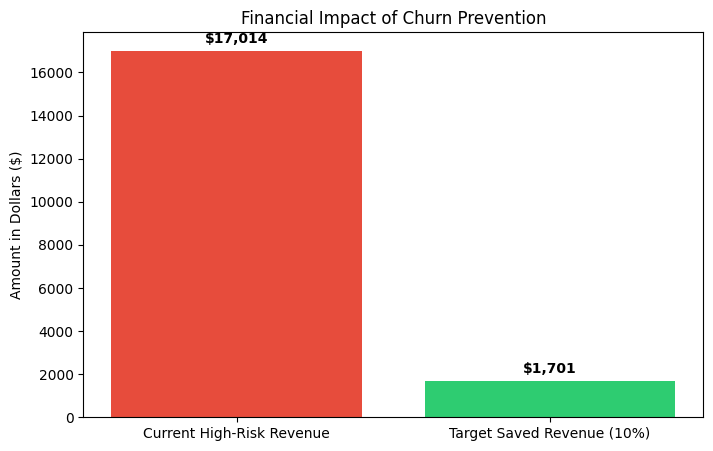


Final report exported: 'Final_Customer_Churn_Priority_List.csv'


In [ ]:

revenue_at_risk = df_final[df_final['Risk_Level'] == 'High Risk']['purchases'].sum()
potential_saved_revenue = revenue_at_risk * 0.10

print(f"Total Revenue at Risk (High Risk Group): ${revenue_at_risk:,.2f}")
print(f"Potential Revenue Saved (10% Conversion): ${potential_saved_revenue:,.2f}")

plt.figure(figsize=(8, 5))
categories = ['Current High-Risk Revenue', 'Target Saved Revenue (10%)']
values = [revenue_at_risk, potential_saved_revenue]

plt.bar(categories, values, color=['#e74c3c', '#2ecc71'])
plt.title('Financial Impact of Churn Prevention')
plt.ylabel('Amount in Dollars ($)')
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.02), f"${v:,.0f}", ha='center', fontweight='bold')
plt.show()

def get_action(row):
    if row['Risk_Level'] == 'High Risk':
        return "Action: 20% Discount + Financial Plan Review"
    elif row['Risk_Level'] == 'Medium Risk':
        return "Action: Loyalty Points Bonus + Personalized Recommendations"
    else:
        return "Action: Early Access to Sales + Credit Limit Increase"

df_final['Marketing_Strategy'] = df_final.apply(get_action, axis=1)

df_final.to_csv('Final_Customer_Churn_Priority_List.csv', index=False)
print("\nFinal report exported: 'Final_Customer_Churn_Priority_List.csv'")

In [ ]:
import pickle

with open('churn_model_final.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as 'churn_model_final.pkl'. You're officially done!")

Model saved as 'churn_model_final.pkl'. You're officially done!
